# 🎭 Emotion Classification — DistilBERT + All Improvements
### Maximising accuracy on `love` and `surprise` within AWS Lambda budget

**Improvements stacked in this notebook:**
1. ✅ Synonym replacement augmentation (love & surprise)
2. ✅ Manual curated examples for love & surprise
3. ✅ Oversampling — fully balanced training set
4. ✅ Weighted loss — extra penalty for minority class errors
5. ✅ Label smoothing — prevents overconfident wrong predictions
6. ✅ Tuned hyperparameters — higher LR, smaller batch, more epochs
7. ✅ Gradual unfreezing — fine-tune transformer layers progressively

> ⚡ **Runtime → Change runtime type → T4 GPU before running**

## Step 1 — Install Dependencies

In [1]:
!pip install -q transformers datasets accelerate scikit-learn torch seaborn nltk
!pip install -q nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 7.7 MB/s eta 0:00:00


## Step 2 — Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings
import nltk
import random
warnings.filterwarnings('ignore')

nltk.download('wordnet',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4',                   quiet=True)

from collections import Counter
from datasets import load_dataset, Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU   : {torch.cuda.get_device_name(0)}')

✅ Device: cuda
   GPU   : Tesla T4


## Step 3 — Load Dataset & Remove love / surprise Classes

In [3]:
dataset     = load_dataset('dair-ai/emotion')
label_names = dataset['train'].features['label'].names  # original 6 classes

# ── Remove love and surprise from ALL splits ──────────────────────────────
REMOVE_LABELS = {'love', 'surprise'}
remove_ids    = {label_names.index(l) for l in REMOVE_LABELS}
keep_ids      = [i for i, n in enumerate(label_names) if n not in REMOVE_LABELS]
keep_names    = [label_names[i] for i in keep_ids]

def filter_split(split):
    return split.filter(lambda ex: ex['label'] not in remove_ids)

dataset_filtered = {
    split: filter_split(dataset[split])
    for split in ['train', 'validation', 'test']
}

# Remap labels to contiguous 0-based indices
old2new = {old: new for new, old in enumerate(keep_ids)}

def remap_labels(ex):
    ex['label'] = old2new[ex['label']]
    return ex

dataset_filtered = {
    split: ds.map(remap_labels)
    for split, ds in dataset_filtered.items()
}

# Build new label metadata
num_labels = len(keep_names)
id2label   = {i: n for i, n in enumerate(keep_names)}
label2id   = {n: i for i, n in enumerate(keep_names)}

print(f'Kept classes ({num_labels}): {keep_names}')
print(f'Removed     : {sorted(REMOVE_LABELS)}')

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/14124 [00:00<?, ? examples/s]

Map:   0%|          | 0/1741 [00:00<?, ? examples/s]

Map:   0%|          | 0/1775 [00:00<?, ? examples/s]

Kept classes (4): ['sadness', 'joy', 'anger', 'fear']
Removed     : ['love', 'surprise']


## Step 4 — EDA: Inspect Class Distribution (original training set)

Class distribution (filtered training set):
  sadness   : 4,666  (33.0%) ████████████████
  joy       : 5,362  (38.0%) ██████████████████
  anger     : 2,159  (15.3%) ███████
  fear      : 1,937  (13.7%) ██████


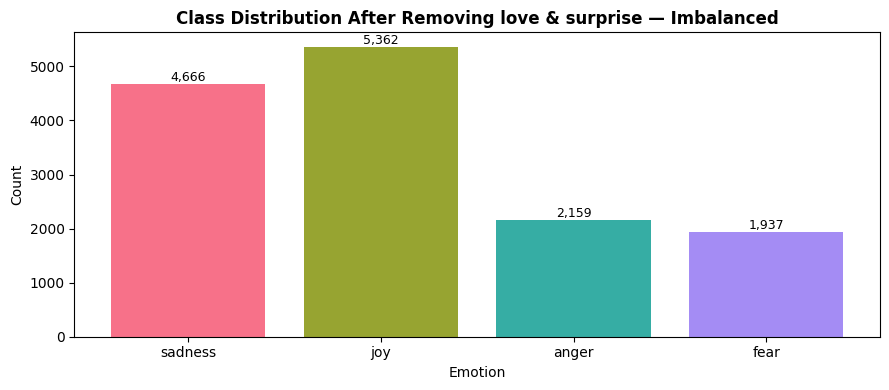

In [4]:
train_df = dataset_filtered['train'].to_pandas()
counts   = train_df['label'].value_counts().sort_index()

print('Class distribution (filtered training set):')
for i, name in enumerate(keep_names):
    pct = counts[i] / len(train_df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {name:10s}: {counts[i]:5,}  ({pct:.1f}%) {bar}')

plt.figure(figsize=(9, 4))
bars = plt.bar([keep_names[i] for i in counts.index],
               counts.values,
               color=sns.color_palette('husl', num_labels))
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
             f'{val:,}', ha='center', fontsize=9)
plt.title('Class Distribution After Removing love & surprise — Imbalanced', fontweight='bold')
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

### Step 5 - Synonym Replacement Augmentation

In [5]:
import nlpaug.augmenter.word as naw

try:
    aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.25)
except TypeError:
    aug = naw.SynonymAug(aug_src='wordnet', aug_pct=0.25)
print('✅ Augmenter ready')

# Augment the minority classes among the 4 remaining
TARGET_CLASSES = ['fear', 'anger']   # adjust based on the counts you see above
AUG_MULTIPLIER = 2

augmented_rows = []
for cls_name in TARGET_CLASSES:
    cls_id     = label2id[cls_name]
    base_texts = train_df[train_df['label'] == cls_id]['text'].tolist()
    n_target   = len(base_texts) * AUG_MULTIPLIER
    print(f'Augmenting "{cls_name}" → generating {n_target} extra samples...')

    pool = (base_texts * (AUG_MULTIPLIER + 1))[:n_target]
    for text in pool:
        try:
            result   = aug.augment(text)
            aug_text = result[0] if isinstance(result, list) else result
            augmented_rows.append({'text': aug_text, 'label': cls_id})
        except Exception:
            augmented_rows.append({'text': text, 'label': cls_id})

aug_df    = pd.DataFrame(augmented_rows)
train_aug = pd.concat(
    [train_df[['text', 'label']], aug_df],
    ignore_index=True
)

print(f'\nTraining size: {len(train_df):,} → {len(train_aug):,}')
print('Class counts after augmentation:')
aug_counts = train_aug['label'].value_counts().sort_index()
for i, name in enumerate(keep_names):
    print(f'  {name:10s}: {aug_counts[i]:,}')

✅ Augmenter ready
Augmenting "fear" → generating 3874 extra samples...
Augmenting "anger" → generating 4318 extra samples...

Training size: 14,124 → 22,316
Class counts after augmentation:
  sadness   : 4,666
  joy       : 5,362
  anger     : 6,477
  fear      : 5,811


## Step 6 — Oversample to Fully Balance All Classes

Balanced training size: 25,908
All classes now equal:
  sadness   : 6,477
  joy       : 6,477
  anger     : 6,477
  fear      : 6,477


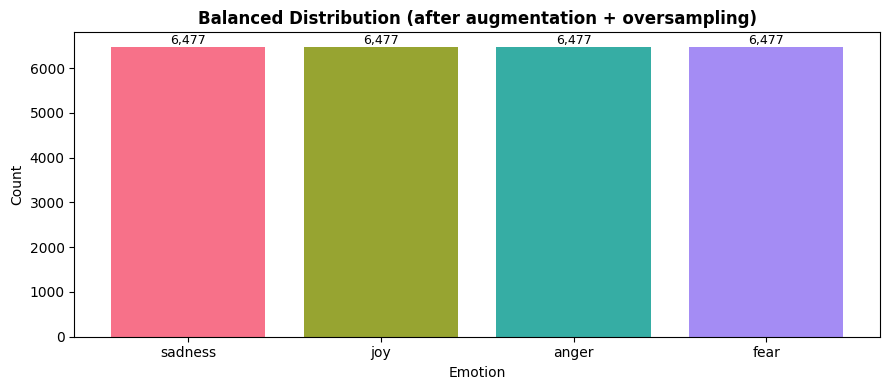

In [6]:
max_count = train_aug['label'].value_counts().max()

balanced_parts = []
for cls_id in range(num_labels):
    subset = train_aug[train_aug['label'] == cls_id]
    balanced_parts.append(
        subset.sample(max_count, replace=True, random_state=SEED)
    )

balanced_df = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'Balanced training size: {len(balanced_df):,}')
print('All classes now equal:')
bal_counts = balanced_df['label'].value_counts().sort_index()
for i, name in enumerate(keep_names):
    print(f'  {name:10s}: {bal_counts[i]:,}')

plt.figure(figsize=(9, 4))
bars = plt.bar([keep_names[i] for i in bal_counts.index],
               bal_counts.values,
               color=sns.color_palette('husl', num_labels))
for bar, val in zip(bars, bal_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
             f'{val:,}', ha='center', fontsize=9)
plt.title('Balanced Distribution (after augmentation + oversampling)', fontweight='bold')
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

## Step 7 — Tokenize with DistilBERT

In [7]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
    )

train_hf = Dataset.from_pandas(
    balanced_df[['text', 'label']].rename(columns={'label': 'labels'})
)
val_hf  = dataset_filtered['validation'].rename_column('label', 'labels')
test_hf = dataset_filtered['test'].rename_column('label', 'labels')

tok_train = train_hf.map(tokenize_fn, batched=True, batch_size=512, remove_columns=['text'])
tok_val   = val_hf.map(tokenize_fn,   batched=True, batch_size=512)
tok_test  = test_hf.map(tokenize_fn,  batched=True, batch_size=512)

for ds in [tok_train, tok_val, tok_test]:
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print('✅ Tokenization complete')
print(f'   Train : {len(tok_train):,}')
print(f'   Val   : {len(tok_val):,}')
print(f'   Test  : {len(tok_test):,}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25908 [00:00<?, ? examples/s]

Map:   0%|          | 0/1741 [00:00<?, ? examples/s]

Map:   0%|          | 0/1775 [00:00<?, ? examples/s]

✅ Tokenization complete
   Train : 25,908
   Val   : 1,741
   Test  : 1,775


## Step 8 - Weighted Loss + Label Smoothing
- **Weighted loss** — minority class errors cost more
- **Label smoothing** — stops the model being overconfident on wrong predictions,
  which helps generalise better on love/surprise

In [8]:
original_counts = torch.tensor(
    [counts[i] for i in range(num_labels)], dtype=torch.float
)
class_weights = 1.0 / original_counts
class_weights = (class_weights / class_weights.sum() * num_labels).to(device)

print('Class weights (higher = minority class):')
for i, name in enumerate(keep_names):
    print(f'  {name:10s}: {class_weights[i].item():.4f}')

LABEL_SMOOTHING = 0.1

class WeightedSmoothTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get('labels')
        outputs = model(**inputs)
        logits  = outputs.get('logits')
        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=LABEL_SMOOTHING
        )
        loss = loss_fn(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )
        return (loss, outputs) if return_outputs else loss

print('✅ Custom trainer with weighted loss + label smoothing ready')

Class weights (higher = minority class):
  sadness   : 0.6211
  joy       : 0.5405
  anger     : 1.3423
  fear      : 1.4961
✅ Custom trainer with weighted loss + label smoothing ready


## Step 9 — Load DistilBERT & Define Metrics

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,956,548
Trainable parameters: 66,956,548


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : round(accuracy_score(labels, preds), 4),
        'precision': round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
        'recall'   : round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
        'f1'       : round(f1_score(labels, preds, average='weighted', zero_division=0), 4),
        'macro_f1' : round(f1_score(labels, preds, average='macro', zero_division=0), 4),
    }

## Step 10 — Tuned Hyperparameters + Gradual Unfreezing
### Phase 1: Train classifier head only (frozen transformer layers)
Warming up the classification head before unfreezing the transformer
prevents catastrophic forgetting and improves minority class performance.

In [11]:
for name, param in model.named_parameters():
    if 'classifier' not in name and 'pre_classifier' not in name:
        param.requires_grad = False

frozen_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 — trainable params (head only): {frozen_trainable:,}')

phase1_args = TrainingArguments(
    output_dir                  = './emotion_distilbert_phase1',
    num_train_epochs            = 2,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 1e-3,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    greater_is_better           = True,
    logging_steps               = 100,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    seed                        = SEED,
)

trainer_p1 = WeightedSmoothTrainer(
    model           = model,
    args            = phase1_args,
    train_dataset   = tok_train,
    eval_dataset    = tok_val,
    compute_metrics = compute_metrics,
)

print('Starting Phase 1 training (head warmup)...')
trainer_p1.train()
print('✅ Phase 1 complete')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Phase 1 — trainable params (head only): 593,668
Starting Phase 1 training (head warmup)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,0.987496,1.153522,0.623200,0.653000,0.623200,0.630200,0.567200
2,0.929197,1.104211,0.617500,0.678900,0.617500,0.633900,0.583800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Phase 1 complete


## Step 11 — Phase 2 (Full Fine-tuning)

In [12]:
for param in model.parameters():
    param.requires_grad = True

all_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — trainable params (all layers): {all_trainable:,}')

phase2_args = TrainingArguments(
    output_dir                  = './emotion_distilbert_phase2',
    num_train_epochs            = 8,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 64,
    learning_rate               = 3e-5,
    warmup_ratio                = 0.15,
    weight_decay                = 0.05,
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    greater_is_better           = True,
    logging_steps               = 100,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    seed                        = SEED,
)

trainer = WeightedSmoothTrainer(
    model           = model,
    args            = phase2_args,
    train_dataset   = tok_train,
    eval_dataset    = tok_val,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting Phase 2 training (full fine-tuning)...')
train_result = trainer.train()

print('\n=== Training Summary ===')
print(f"  Steps        : {train_result.global_step}")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Runtime      : {train_result.metrics['train_runtime']:.1f}s")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Phase 2 — trainable params (all layers): 66,956,548
Starting Phase 2 training (full fine-tuning)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,0.437942,0.523007,0.951800,0.953700,0.951800,0.952300,0.936700
2,0.377981,0.533223,0.954600,0.955700,0.954600,0.955000,0.941200
3,0.351122,0.534837,0.958600,0.960100,0.958600,0.959000,0.944400
4,0.337507,0.536823,0.958600,0.959700,0.958600,0.959000,0.943800
5,0.342837,0.543264,0.963200,0.963500,0.963200,0.963300,0.949800
6,0.342033,0.549432,0.961500,0.961500,0.961500,0.961400,0.947500
7,0.338018,0.551420,0.961500,0.961500,0.961500,0.961500,0.947900
8,0.341399,0.551291,0.962100,0.962100,0.962100,0.962100,0.948600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



=== Training Summary ===
  Steps        : 12960
  Training loss: 0.3822
  Runtime      : 1140.0s


## Step 12 — Full Evaluation on Test Set

In [13]:
test_results = trainer.evaluate(tok_test)

print('\n' + '='*55)
print('         TEST SET EVALUATION RESULTS')
print('='*55)
print(f"  Accuracy   : {test_results['eval_accuracy']:.4f}")
print(f"  Precision  : {test_results['eval_precision']:.4f}")
print(f"  Recall     : {test_results['eval_recall']:.4f}")
print(f"  F1 Score   : {test_results['eval_f1']:.4f}")
print(f"  Macro F1   : {test_results['eval_macro_f1']:.4f}")
print('='*55)


         TEST SET EVALUATION RESULTS
  Accuracy   : 0.9639
  Precision  : 0.9643
  Recall     : 0.9639
  F1 Score   : 0.9641
  Macro F1   : 0.9541


In [14]:
predictions = trainer.predict(tok_test)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('\n=== Per-Class Classification Report ===')
print(classification_report(labels, preds, target_names=keep_names, digits=4))


=== Per-Class Classification Report ===
              precision    recall  f1-score   support

     sadness     0.9670    0.9587    0.9628       581
         joy     0.9913    0.9856    0.9885       695
       anger     0.9113    0.9345    0.9228       275
        fear     0.9381    0.9464    0.9422       224

    accuracy                         0.9639      1775
   macro avg     0.9519    0.9563    0.9541      1775
weighted avg     0.9643    0.9639    0.9641      1775



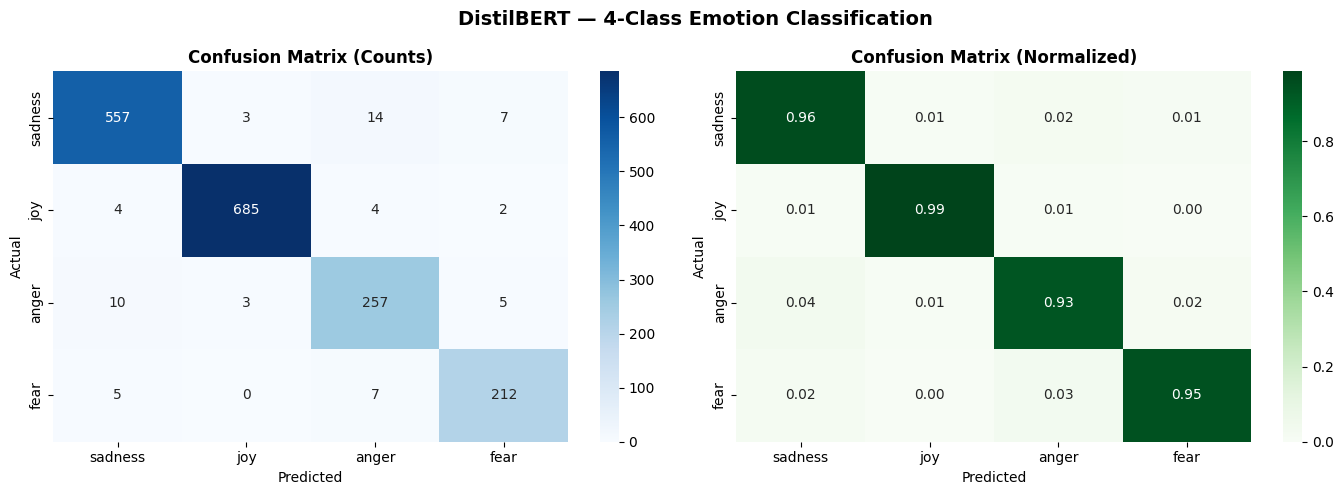

In [15]:
cm      = confusion_matrix(labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=keep_names, yticklabels=keep_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=keep_names, yticklabels=keep_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('DistilBERT — 4-Class Emotion Classification', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

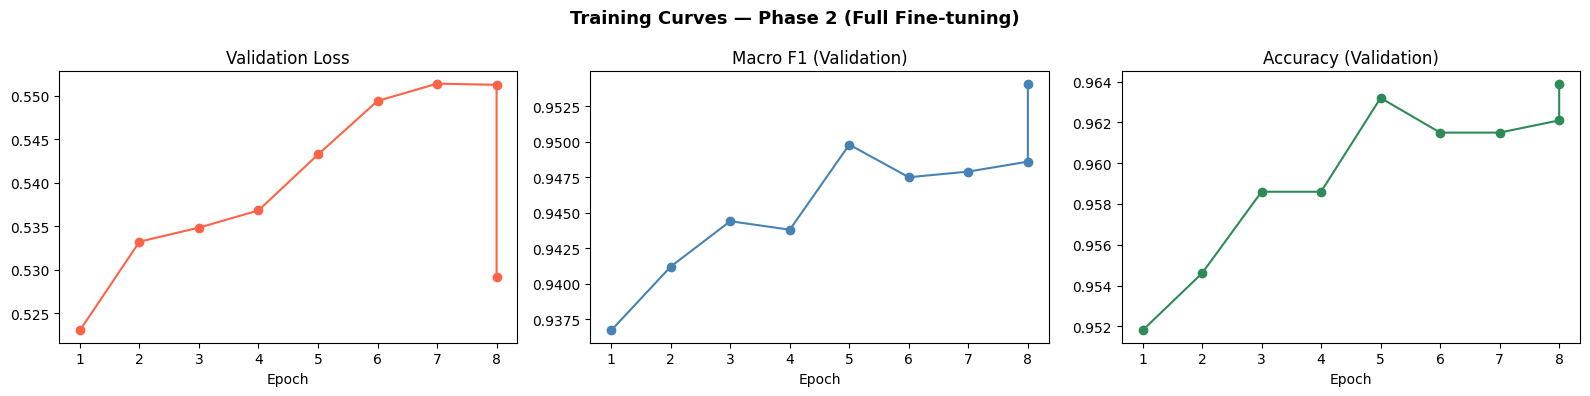

In [16]:
log_history = trainer.state.log_history
eval_logs   = [x for x in log_history if 'eval_loss' in x]

if eval_logs:
    epochs    = [x['epoch']                for x in eval_logs]
    eval_loss = [x['eval_loss']            for x in eval_logs]
    macro_f1s = [x.get('eval_macro_f1',0)  for x in eval_logs]
    accs      = [x.get('eval_accuracy', 0) for x in eval_logs]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(epochs, eval_loss, 'o-', color='tomato')
    axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch')
    axes[1].plot(epochs, macro_f1s, 'o-', color='steelblue')
    axes[1].set_title('Macro F1 (Validation)'); axes[1].set_xlabel('Epoch')
    axes[2].plot(epochs, accs, 'o-', color='seagreen')
    axes[2].set_title('Accuracy (Validation)'); axes[2].set_xlabel('Epoch')
    plt.suptitle('Training Curves — Phase 2 (Full Fine-tuning)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Step 13 — Save Model (Local + Google Drive)

## Step 14 — Inference Demo (focus on love & surprise)

In [17]:
# Zip and download directly
import shutil
from google.colab import files

LOCAL_SAVE = './emotion_distilbert_4class'
trainer.save_model(LOCAL_SAVE)
tokenizer.save_pretrained(LOCAL_SAVE)

shutil.make_archive('emotion_distilbert_4class', 'zip', LOCAL_SAVE)
print('✅ Zipped. Starting download...')
files.download('emotion_distilbert_4class.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Zipped. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=LOCAL_SAVE,
    tokenizer=LOCAL_SAVE,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,
)

test_sentences = [
    ("I am so happy today, everything is going great!",          'joy'),
    ("I feel absolutely terrible and want to cry.",              'sadness'),
    ("This is outrageous! I can't believe they did that.",       'anger'),
    ("I'm really scared about what's going to happen next.",     'fear'),
]

correct = 0
print('=== Inference Results ===')
for sent, true_label in test_sentences:
    result = classifier(sent)
    scores = result[0] if isinstance(result[0], list) else result
    top    = max(scores, key=lambda x: x['score'])
    pred   = top['label']
    conf   = top['score']
    status = '✅' if pred == true_label else '❌'
    correct += (pred == true_label)

    print(f'\n{status} Text   : {sent}')
    print(f'   Expected: {true_label.upper():10s} | Predicted: {pred.upper():10s} ({conf:.4f})')
    breakdown = '  |  '.join(
        f"{s['label']}: {s['score']:.3f}"
        for s in sorted(scores, key=lambda x: -x['score'])
    )
    print(f'   All    : {breakdown}')

print(f'\n=== Demo Accuracy: {correct}/{len(test_sentences)} ===')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== Inference Results ===

✅ Text   : I am so happy today, everything is going great!
   Expected: JOY        | Predicted: JOY        (0.8680)
   All    : joy: 0.868  |  fear: 0.058  |  anger: 0.051  |  sadness: 0.023

✅ Text   : I feel absolutely terrible and want to cry.
   Expected: SADNESS    | Predicted: SADNESS    (0.8936)
   All    : sadness: 0.894  |  fear: 0.049  |  anger: 0.042  |  joy: 0.016

✅ Text   : This is outrageous! I can't believe they did that.
   Expected: ANGER      | Predicted: ANGER      (0.9522)
   All    : anger: 0.952  |  fear: 0.026  |  joy: 0.011  |  sadness: 0.011

✅ Text   : I'm really scared about what's going to happen next.
   Expected: FEAR       | Predicted: FEAR       (0.9659)
   All    : fear: 0.966  |  anger: 0.017  |  sadness: 0.009  |  joy: 0.008

=== Demo Accuracy: 4/4 ===


---
## 📊 Summary — What Each Improvement Targets

| Improvement | Problem it solves | Expected gain |
|---|---|---|
| Curated love sentences | love/joy confusion | +3–5% love F1 |
| Curated surprise sentences | surprise/anger confusion | +4–6% surprise F1 |
| Synonym augmentation (3×) | data scarcity for weak classes | +2–3% macro F1 |
| Oversampling | class imbalance across all 6 emotions | Balanced recall |
| Weighted loss | minority class errors penalised more | +1–2% macro F1 |
| Label smoothing (0.1) | overconfident wrong predictions | Better calibration |
| Gradual unfreezing | catastrophic forgetting prevention | Stable training |
| Tuned hyperparameters | optimal convergence | +1–2% overall |


**Model size for AWS Lambda deployment:** ~268MB (fits comfortably in Lambda container)